# DAAAnalyzer_1.0_PlotDPOAEs.ipynb
Created by: JFranco | Created On: 26 NOV 2024 | Last Env: QISHA | Last Run Date: 20 JAN 2025

This Python notebook will read in the existing file that compiled DPOAE f2 thresholds for all subjects to
generate a plot. It will also output the groupby describe values for this run. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters for plotting
conditions = ["Pink","Blue","NonInj"]
pltOrder = conditions
colors = {pltOrder[0]:'mediumorchid',pltOrder[1]:'slateblue', pltOrder[2]:'black'}
legColors = ["mediumorchid","slateblue",'black']

In [2]:
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]

In [3]:
#                *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_010'
daaRun = '1'
daaType = 'Pre Noise Exposure'

# Directories 
#   - Existing ones -
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/DAA/'
dirPrep = dirMain+prepID+'/'
dirData = dirPrep+'RawData/'
dirMD = dirPrep+'Metadata/'
dirDFs = dirPrep+"Results/1_CompiledMeasurements/"
dirDPOAEs = dirPrep+"Results/2_DPOAEPlotsByGroup/"

# Filenames
#    - Existing Ones - 
#fnMD = 'CMI_005.Metadata.AnimalInfo.csv'
fnDPs = prepID+'.DPOAEf2Thresholds.DAA_'+daaRun+'.csv'
isoFile = 'IsoDP-'+daaRun+'-1.tsv'

#    - Ones that will be made - 
fnPltDP = prepID+'.DPOAEf2Thresholds.DAA_'+daaRun+'.png'
fnGBDPs = prepID+'.GroupDPOAEStats.DAA_'+daaRun+'.csv'

In [4]:
# *** LOAD DPOAE DATA **
# Sample metadata sheet that include animal and condition info
dfDPs = pd.read_csv(dirDFs+fnDPs, index_col=0)

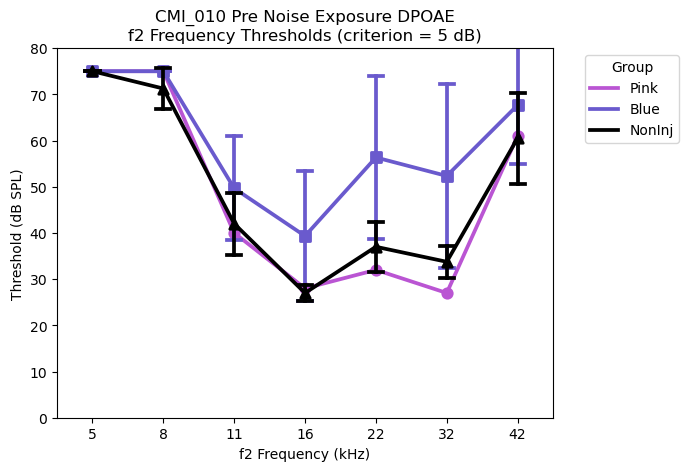

In [5]:
# *** SET PLOT SPECIFIC PARAMETERS ***
plot = "DPOAEs.DAA_"+daaRun
plottype = "PtPlt"
title = prepID+" "+daaType+" DPOAE\n"+"f2 Frequency Thresholds (criterion = 5 dB)"
hue = 'InjGroup'
x = "f2Freq_kHz"
y="Thresh_dBSPL"
xlab = "f2 Frequency (kHz)"
ylab = "Threshold (dB SPL)"
ymin = 0
ymax = 80

# *** MAKE PLOT ***
# Code for two styles of plots are shown below 
# Uncomment code below for an alternate plot style (i.e., points connected by a line at average with errorbars)
#ax = sns.lineplot(data=dfDPs,x=x, y=y, hue=hue,palette=colors)
ax = sns.pointplot(data=dfDPs,x=x, y=y, hue=hue,markers=["o","s","^"], linestyles=["-", "-","-"],
                   errorbar='sd', capsize=.2, palette=colors)

plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
leg = ax.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
ax.set_title(title)
ax.set(xlabel=xlab)
ax.set(ylabel=ylab)
ax.set_ylim((ymin, ymax))

# *** SAVE THE FIGURE ***
plt.savefig(dirDPOAEs+fnPltDP,  bbox_inches='tight', dpi = 300,format = 'png')

In [6]:
# *** CALCULATE AND SAVE GROUPBY DESCRIBE INFO ***
# Drop columns that are not needed for groupby stats
df = dfDPs.drop(['AnimalID','CMIID','DAA_Run','Sex'], axis=1)
grpDPs = df.groupby(['InjGroup', 'f2Freq_kHz'])
grpDPsStats = grpDPs.describe()
grpDPsStats.to_csv(dirDFs+fnGBDPs, index=True)
grpDPsStats

Thresh_dBSPL                                           \
                           count       mean        std   min    25%   50%   
InjGroup f2Freq_kHz                                                         
Blue     5                   3.0  75.000000   0.000000  75.0  75.00  75.0   
         8                   3.0  75.000000   0.000000  75.0  75.00  75.0   
         11                  3.0  49.666667  11.239810  40.0  43.50  47.0   
         16                  3.0  39.333333  14.011900  28.0  31.50  35.0   
         22                  3.0  56.333333  17.616280  40.0  47.00  54.0   
         32                  3.0  52.333333  19.857828  38.0  41.00  44.0   
         42                  3.0  67.666667  12.701706  53.0  64.00  75.0   
NonInj   5                   4.0  75.000000   0.000000  75.0  75.00  75.0   
         8                   4.0  71.250000   4.500000  66.0  68.25  72.0   
         11                  4.0  42.000000   6.733003  38.0  38.00  39.0   
         16                  4.0  27.000000   1.632993  25.0  26.50  27.0   
         22                  4.0  37.000000   5.416026  29.0  36.50  39.0   
         32                  4.0  33.750000   3.403430  29.0  32.75  34.5   
         42                  4.0  60.500000   9.814955  54.0  54.75  56.5   
Pink     5                   1.0  75.000000        NaN  75.0  75.00  75.0   
         8                   1.0  75.000000        NaN  75.0  75.00  75.0   
         11                  1.0  40.000000        NaN  40.0  40.00  40.0   
         16                  1.0  28.000000        NaN  28.0  28.00  28.0   
         22                  1.0  32.000000        NaN  32.0  32.00  32.0   
         32                  1.0  27.000000        NaN  27.0  27.00  27.0   
         42                  1.0  61.000000        NaN  61.0  61.00  61.0   

                                  
                       75%   max  
InjGroup f2Freq_kHz               
Blue     5           75.00  75.0  
         8           75.00  75.0  
         11          54.50  62.0  
         16          45.00  55.0  
         22          64.50  75.0  
         32          59.50  75.0  
         42          75.00  75.0  
NonInj   5           75.00  75.0  
         8           75.00  75.0  
         11          43.00  52.0  
         16          27.50  29.0  
         22          39.50  41.0  
         32          35.50  37.0  
         42          62.25  75.0  
Pink     5           75.00  75.0  
         8           75.00  75.0  
         11          40.00  40.0  
         16          28.00  28.0  
         22          32.00  32.0  
         32          27.00  27.0  
         42          61.00  61.0